# Raw Data Notebook
In this notebook, we do not perform any cleaning or preprocessing steps on the dataset. Instead, we work directly with the raw data in its original form. This approach allows us to explore the dataset as it was generated, without introducing transformations or modifications that could alter its structure or distribution

In [13]:
# Import pandas and numpy for data manipulation

import pandas as pd
import numpy as np

# Import matplotlib and seaborn for visualization

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

In [14]:
df = pd.read_csv("data/bank_customers.csv")

# Clustering

In [20]:
# Define the raw features to be used for clustering 
raw_features = [
    'age', 'monthly_income', 'monthly_expenses',
    'account_tenure_years', 'monthly_transactions',
    'avg_transaction_value', 'digital_login_frequency',
    'branch_visit_count', 'late_payment_count',
    'has_savings_account', 'has_credit_card', 'has_home_loan',
    'has_personal_loan', 'has_vehicle_finance', 'has_investment_account',
    'active_products_count', 'credit_score',
    'loan_utilisation_rate', 'days_since_last_default',
    'number_of_dependents'
]

No scaling on the data. We will use the raw features directly for KMeans clustering to determine the optimal number of clusters using the Elbow Method Aand the Silhouette Method.


K=2 | Inertia: 373402067659.61
K=3 | Inertia: 219048315925.90
K=4 | Inertia: 145427554612.36
K=5 | Inertia: 112828876855.91
K=6 | Inertia: 92638290257.50
K=7 | Inertia: 77748266811.13
K=8 | Inertia: 67166151203.46
K=9 | Inertia: 57146368895.59
K=10 | Inertia: 50044442964.10


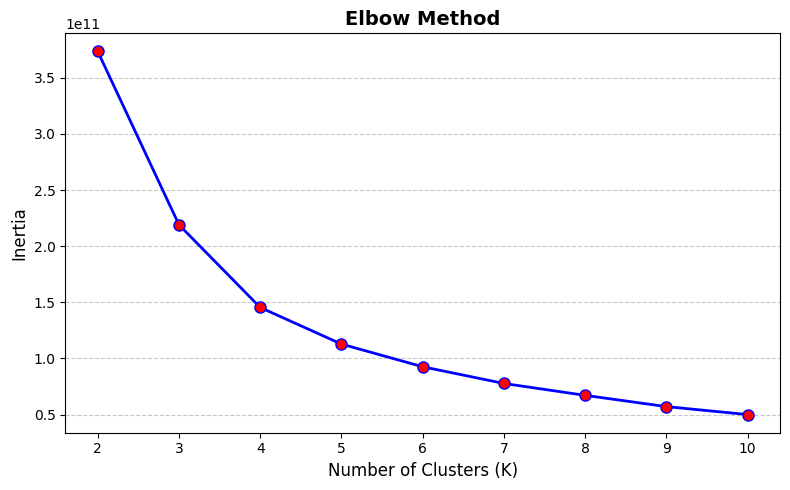

In [21]:
X = df[raw_features]

# Elbow Method to determine optimal K

k_range = range(2, 11)
inertia = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42, max_iter=300)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    print(f"K={k} | Inertia: {kmeans.inertia_:.2f}")

fig,ax = plt.subplots(figsize=(8, 5))

ax.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8, markerfacecolor='red')
ax.set_xlabel("Number of Clusters (K)", fontsize=12)
ax.set_ylabel("Inertia", fontsize=12)
ax.set_title("Elbow Method", fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

K=2 | Silhouette Score: 0.6379
K=3 | Silhouette Score: 0.5424
K=4 | Silhouette Score: 0.5193
K=5 | Silhouette Score: 0.4348
K=6 | Silhouette Score: 0.4070
K=7 | Silhouette Score: 0.4314
K=8 | Silhouette Score: 0.4596
K=9 | Silhouette Score: 0.4575
K=10 | Silhouette Score: 0.4693


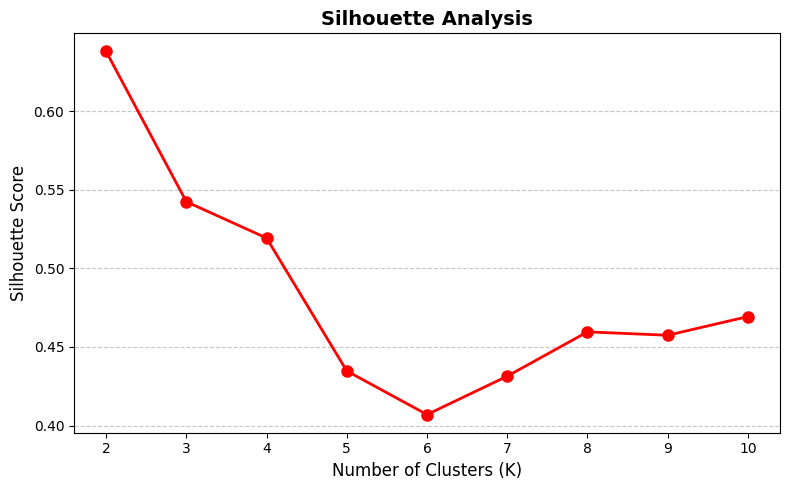

In [22]:
# Silhouette Analysis to determine optimal K
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42, max_iter=300)
    cluster_labels = kmeans.fit_predict(X)
    score = silhouette_score(X, cluster_labels, sample_size=500, random_state=42)
    silhouette_scores.append(score)
    print(f"K={k} | Silhouette Score: {score:.4f}")

fig,ax = plt.subplots(figsize=(8, 5))

ax.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax.set_xlabel("Number of Clusters (K)", fontsize=12)
ax.set_ylabel("Silhouette Score", fontsize=12)
ax.set_title("Silhouette Analysis", fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Choosing the Optimal Number of Clusters

From the Elbow plot, the elbow point appears at K=4. We choose this value as our optimal number of clusters.

In [19]:
OPTIMAL_K = 4

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, 
                      init='k-means++', n_init=10, max_iter=300)
final_labels = kmeans_final.fit_predict(X)
df['cluster'] = final_labels

In [23]:
# Analyze cluster characteristics
cluster_counts = df['cluster'].value_counts().sort_index()
print("Cluster Counts:")
print(cluster_counts)
print(f"\nSmallest cluster has {cluster_counts.min()} customers, largest has {cluster_counts.max()} customers")

Cluster Counts:
cluster
0     279
1    1083
2      78
3     560
Name: count, dtype: int64

Smallest cluster has 78 customers, largest has 1083 customers


### Cluster Profiling

In [26]:
# Profile clusters based on key features. Use original data, unscaled and with categorical features in their original form for interpretability.

profile_features = [
    # Financial features
    'monthly_income', 'monthly_expenses', 'account_tenure_years',
    # Risk features
    'credit_score', 'loan_utilisation_rate', 'late_payment_count',
    # Behavioural features
    'digital_login_frequency', 'branch_visit_count',
    'monthly_transactions', 'avg_transaction_value',
    # Product features
    'active_products_count', 'has_credit_card', 'has_home_loan',
    'has_personal_loan', 'has_vehicle_finance', 'has_investment_account',
    # Target feature
    'churn_risk_label'
] 

# Mean of numerical features per cluster
cluster_profile = df.groupby('cluster')[profile_features[:-1]].mean().round(3)

In [27]:
cluster_profile

,monthly_income,monthly_expenses,account_tenure_years,credit_score,loan_utilisation_rate,late_payment_count,digital_login_frequency,branch_visit_count,monthly_transactions,avg_transaction_value,active_products_count,has_credit_card,has_home_loan,has_personal_loan,has_vehicle_finance,has_investment_account
cluster,,,,,,,,,,,,,,,,
0,46400.717,27804.301,7.338,641.835,0.408,1.685,17.294,3.072,40.226,730.330,4.548,0.892,0.835,0.570,0.703,0.548
1,5811.907,3997.045,5.136,554.157,0.262,2.397,12.485,3.762,13.965,406.064,1.448,0.227,0.056,0.250,0.118,0.005
2,80447.436,48312.821,9.723,686.449,0.356,1.538,20.385,3.333,63.795,772.908,4.692,0.910,0.756,0.577,0.782,0.667
3,22410.253,13614.643,6.179,607.786,0.416,1.673,14.298,3.516,25.620,579.697,3.277,0.664,0.416,0.511,0.514,0.188


In [28]:
# Find the most common churn risk label per cluster
cluster_profile['dominant_churn_risk'] = (
    df.groupby('cluster')['churn_risk_label']
    .agg(lambda x: x.value_counts().index[0])
)

# cluster size
cluster_profile['cluster_size'] = df['cluster'].value_counts().sort_index()

print(cluster_profile.T)  # Transpose for better readability

cluster                          0         1          2          3
monthly_income           46400.717  5811.907  80447.436  22410.253
monthly_expenses         27804.301  3997.045  48312.821  13614.643
account_tenure_years         7.338     5.136      9.723      6.179
credit_score               641.835   554.157    686.449    607.786
loan_utilisation_rate        0.408     0.262      0.356      0.416
late_payment_count           1.685     2.397      1.538      1.673
digital_login_frequency     17.294    12.485     20.385     14.298
branch_visit_count           3.072     3.762      3.333      3.516
monthly_transactions        40.226    13.965     63.795      25.62
avg_transaction_value       730.33   406.064    772.908    579.697
active_products_count        4.548     1.448      4.692      3.277
has_credit_card              0.892     0.227       0.91      0.664
has_home_loan                0.835     0.056      0.756      0.416
has_personal_loan             0.57      0.25      0.577      0

#### Visualize the clusters

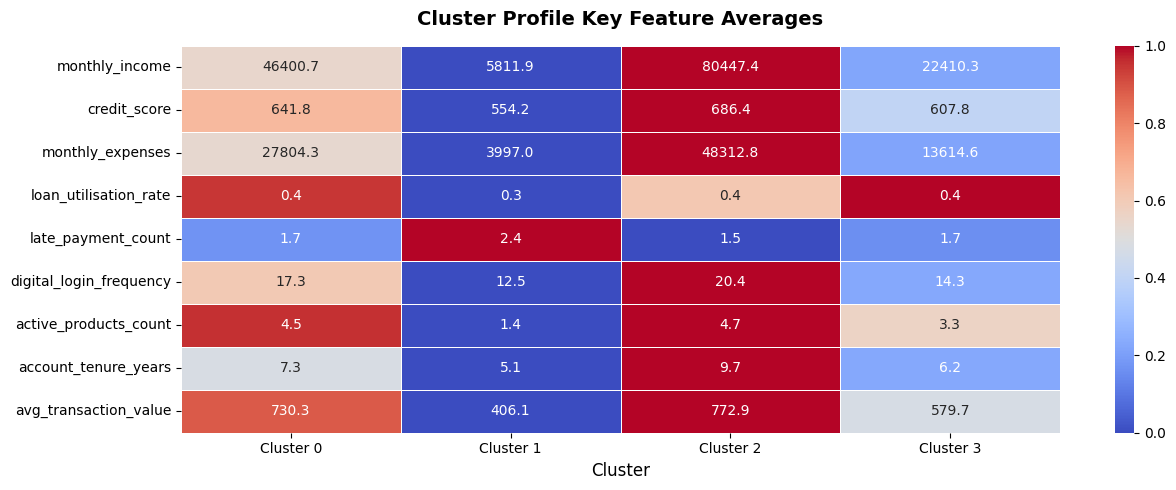

In [30]:
heatmap_features = [
    'monthly_income', 'credit_score', 'monthly_expenses',
    'loan_utilisation_rate', 'late_payment_count',
    'digital_login_frequency', 'active_products_count',
    'account_tenure_years', 'avg_transaction_value'
]

# Normalise profile values to 0-1 for visualization
profile_heatmap = cluster_profile[heatmap_features].copy()
profile_normalised = (profile_heatmap - profile_heatmap.min()) / (
    profile_heatmap.max() - profile_heatmap.min()
)

fig, ax = plt.subplots(figsize=(13, 5))

sns.heatmap(
    profile_normalised.T,       # Transpose 
    annot=cluster_profile[heatmap_features].T,  # Show actual values not normalised
    fmt=".1f",
    cmap="coolwarm",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Cluster Profile Key Feature Averages",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Cluster", fontsize=12)
ax.set_ylabel("")
ax.set_xticklabels([f"Cluster {i}" for i in range(OPTIMAL_K)], rotation=0)

plt.tight_layout()
plt.show()

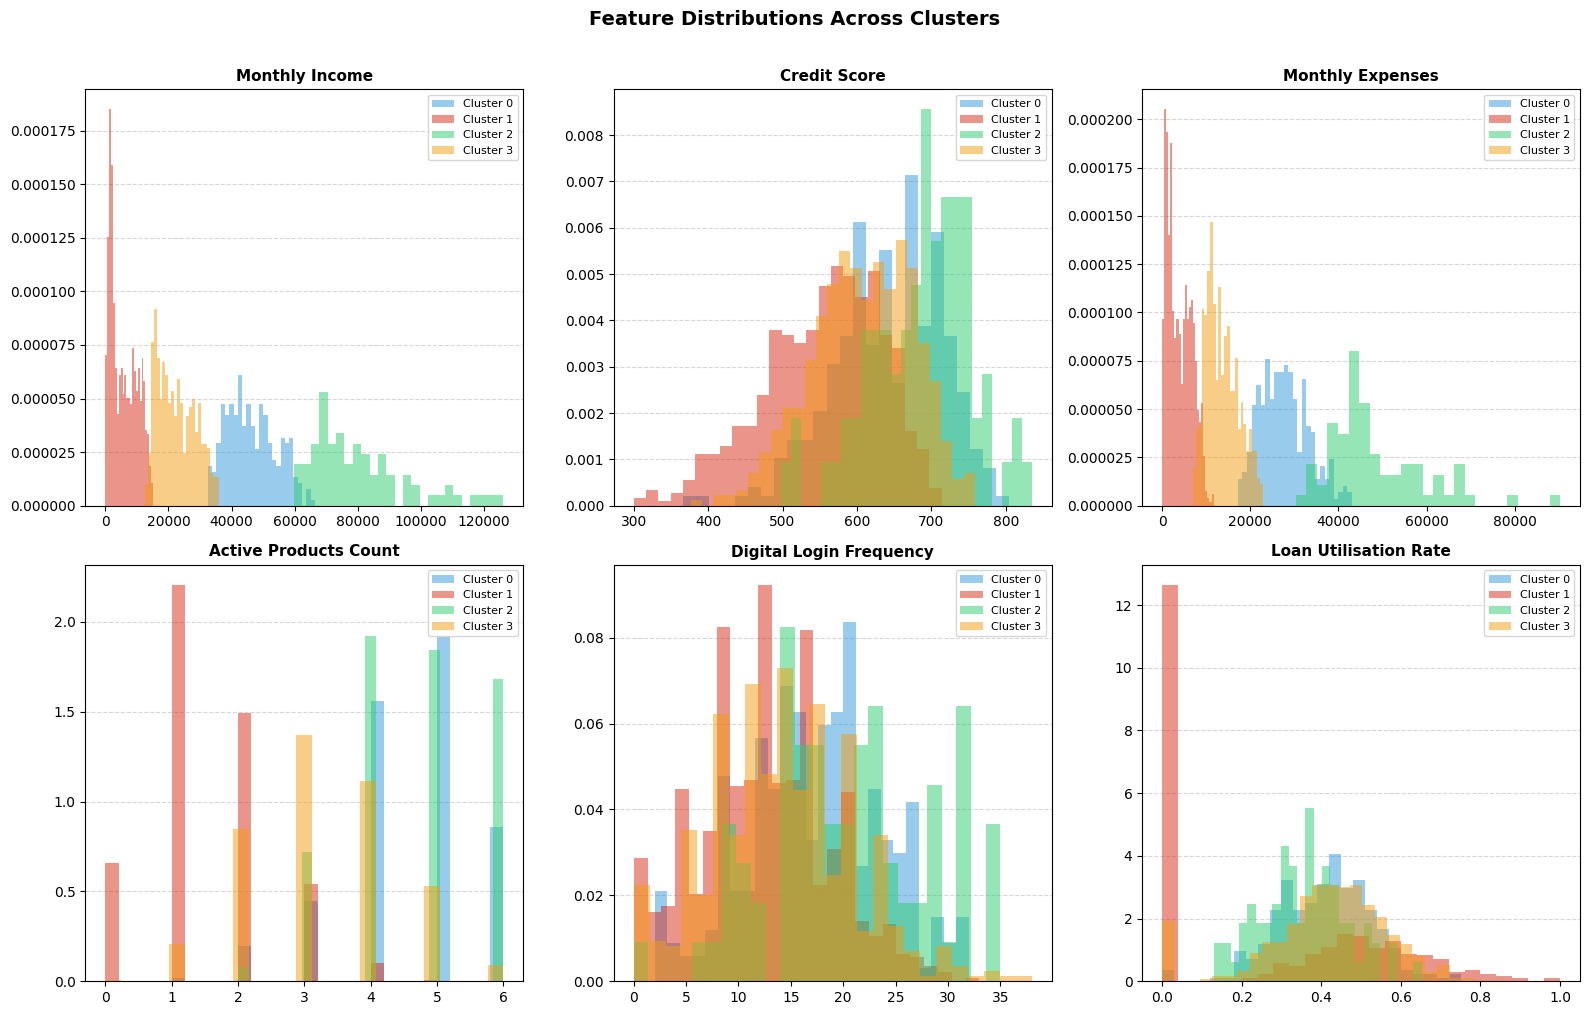

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

distribution_features = [
    'monthly_income', 'credit_score', 'monthly_expenses',
    'active_products_count', 'digital_login_frequency', 'loan_utilisation_rate'
]

cluster_palette = {0: "#3498db", 1: "#d82a17", 2: "#2ecc71", 3: "#f39c12"}

for idx, feature in enumerate(distribution_features):
    for cluster_id in range(OPTIMAL_K):
        cluster_data = df[df['cluster'] == cluster_id][feature]
        axes[idx].hist(
            cluster_data,
            bins=25,
            alpha=0.5,
            label=f"Cluster {cluster_id}",
            color=cluster_palette[cluster_id],
            density=True        # Normalise so clusters of different sizes are comparable
        )
    axes[idx].set_title(feature.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("")
    axes[idx].legend(fontsize=8)
    axes[idx].yaxis.grid(True, linestyle='--', alpha=0.5)
    axes[idx].set_axisbelow(True)

plt.suptitle("Feature Distributions Across Clusters",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Potential cluster names based on the cluster distributions

In [41]:
cluster_names = {
    0: "Affluent & Stable",
    1: "Financially Vulnerable",
    2: "High Networth ",
    3: "Stable Middles"
}

df['cluster_name'] = df['cluster'].map(cluster_names)
print(df['cluster_name'].value_counts())

cluster_name
Financially Vulnerable    1083
Stable Middles             560
Affluent & Stable          279
High Networth               78
Name: count, dtype: int64


# Recommendation Engine

### Product Catalogoue

In [46]:
product_catalogue = {
    "Credit Card": {
        "description": "Revolving credit facility for everyday purchases",
        "min_income": 6000,
        "min_credit_score": 580,
        "target_segments": ["Stable Middles", "High Networth ", "Affluent & Stable"],
        "existing_column": "has_credit_card"
    },
    "Home Loan": {
        "description": "Long-term mortgage for property purchase",
        "min_income": 20000,
        "min_credit_score": 620,
        "target_segments": ["Stable Middles", "High Networth ", "Affluent & Stable"],
        "existing_column": "has_home_loan"
    },
    "Vehicle Finance": {
        "description": "Installment finance for vehicle purchase",
        "min_income": 12000,
        "min_credit_score": 580,
        "target_segments": ["Stable Middles", "High Networth ", "Affluent & Stable"],
        "existing_column": "has_vehicle_finance"
    },
    "Personal Loan": {
        "description": "Unsecured loan for personal expenses",
        "min_income": 6000,
        "min_credit_score": 550,
        "target_segments": ["Stable Middles", "Affluent & Stable","High Networth "],
        "existing_column": "has_personal_loan"
    },
    "Investment Account": {
        "description": "Unit trust or fixed investment for wealth accumulation",
        "min_income": 25000,
        "min_credit_score": 620,
        "target_segments": ["High Networth ", "Affluent & Stable"],
        "existing_column": "has_investment_account"
    },
    "Fixed Deposit": {
        "description": "Guaranteed return savings over a fixed term",
        "min_income": 6000,
        "min_credit_score": 500,
        "target_segments": ["Stable Middles", "High Networth ", "Affluent & Stable"],
        "existing_column": None  # New product
    },
    "Overdraft Facility": {
        "description": "Short-term credit buffer linked to cheque account",
        "min_income": 6000,
        "min_credit_score": 560,
        "target_segments": ["Stable Middles", "High Networth ", "Affluent & Stable"],
        "existing_column": None  # New product
    },
    "Revolving Credit": {
        "description": "Flexible credit facility that replenishes as you repay",
        "min_income": 10000,
        "min_credit_score": 570,
        "target_segments": ["Stable Middles", "High Networth ", "Affluent & Stable"],
        "existing_column": None  # New product
    },
    "Rewards Programme": {
        "description": "Points-based loyalty programme with lifestyle benefits",
        "min_income": 15000,
        "min_credit_score": 580,
        "target_segments": ["High Networth ", "Stable Middles","Affluent & Stable"],
        "existing_column": None  # New product
    },
    "Financial Wellness Plan": {
        "description": "Debt counselling and budgeting support programme",
        "min_income": 0,      
        "min_credit_score": 0, 
        "target_segments": ["Financially Vulnerable"],
        "existing_column": None
    },
    "Youth Savings Accoutn": {
        "description": "Entry level savings account with goal-based features for new earners",
        "min_income": 3000,
        "min_credit_score": 0,
        "target_segments": ["Stable Middles"],
        "existing_column": None

    }
}


### Product Owndership

In [47]:
# compute ownership rates for products that exist in the data, by cluster
tracked_products = {
    name: details for name, details in product_catalogue.items()
    if details['existing_column'] is not None
}

# ownership rate table
ownership_rates = {}
for product_name, details in tracked_products.items():
    col = details['existing_column']
    rates = df.groupby('cluster_name')[col].mean().mul(100).round(1)
    ownership_rates[product_name] = rates

ownership_df = pd.DataFrame(ownership_rates)
print("\nProduct Ownership Rates by Cluster (%):")
print(ownership_df.to_string())


Product Ownership Rates by Cluster (%):
                        Credit Card  Home Loan  Vehicle Finance  Personal Loan  Investment Account
cluster_name                                                                                      
Affluent & Stable              89.2       83.5             70.3           57.0                54.8
Financially Vulnerable         22.7        5.6             11.8           25.0                 0.5
High Networth                  91.0       75.6             78.2           57.7                66.7
Stable Middles                 66.4       41.6             51.4           51.1                18.8


### Recommendation Logic

In [49]:
def recommend_products_for_cluster(cluster_name, cluster_profile_row, top_n=3):
    
    """
    Recommends top N products for a given cluster based on:
    - Segment eligibility
    - Financial eligibility
    - Ownership gap
    
    Parameters
    ----------
    cluster_name: str
                - name of the cluster
    cluster_profile_row: Series 
                        - mean feature values for this cluster
    top_n: int   
        — number of products to recommend
    
    Returns
    -------
    List of recommended product names with reasoning
    """
    avg_income       = cluster_profile_row['monthly_income']
    avg_credit_score = cluster_profile_row['credit_score']
    
    recommendations = []
    
    for product_name, details in product_catalogue.items():
        
        # Don't do anything if the product isn't targeted at this segment
        if cluster_name not in details['target_segments']:
            continue
        
        # Don't do anything if the cluster doesn't meet the financial eligibility criteria
        if avg_income < details['min_income']:
            continue

        # Don't do anything if the cluster doesn't meet the credit score eligibility criteria
        if avg_credit_score < details['min_credit_score']:
            continue
        
        # Compute ownership gap score for products that exist in the data. 
        # For new products, we assume maximum gap (1.0) since no one has it yet.
        if details['existing_column'] is not None:
            col = details['existing_column']
            ownership_rate = df[df['cluster_name'] == cluster_name][col].mean()
            gap_score = 1 - ownership_rate 
        else:
            gap_score = 1.0 # Max gap for new products
        
        recommendations.append({
            'product': product_name,
            'description': details['description'],
            'gap_score': round(gap_score, 3),
            'ownership_rate': round((ownership_rate) * 100, 1) if details['existing_column'] else 0.0
        })
    
    # Sort by gap score descending — biggest opportunity first
    recommendations = sorted(recommendations, key=lambda x: x['gap_score'], reverse=True)
    
    return recommendations[:top_n]


print("=" * 65)
print("PRODUCT RECOMMENDATIONS BY CUSTOMER SEGMENT")
print("=" * 65)

cluster_recommendations = {}

for cluster_id in range(OPTIMAL_K):
    cluster_name = cluster_names[cluster_id]
    profile_row  = cluster_profile.loc[cluster_id]
    recs         = recommend_products_for_cluster(cluster_name, profile_row, top_n=3)
    cluster_recommendations[cluster_name] = recs
    
    print(f"\n{'─' * 65}")
    print(f"  {cluster_name.upper()}")
    print(f"  Avg Income: R{profile_row['monthly_income']:,.0f} | "
          f"Credit Score: {profile_row['credit_score']:.0f} | "
          f"Products Held: {profile_row['active_products_count']:.1f}")
    print(f"{'─' * 65}")
    
    for i, rec in enumerate(recs, 1):
        ownership_str = (f"Current ownership: {rec['ownership_rate']:.0f}%"
                        if rec['ownership_rate'] > 0 else "New product offering")
        print(f"  {i}. {rec['product']}")
        print(f"     → {rec['description']}")
        print(f"     → {ownership_str} | Gap score: {rec['gap_score']:.3f}")

print(f"\n{'=' * 65}")

PRODUCT RECOMMENDATIONS BY CUSTOMER SEGMENT

─────────────────────────────────────────────────────────────────
  AFFLUENT & STABLE
  Avg Income: R46,401 | Credit Score: 642 | Products Held: 4.5
─────────────────────────────────────────────────────────────────
  1. Fixed Deposit
     → Guaranteed return savings over a fixed term
     → New product offering | Gap score: 1.000
  2. Overdraft Facility
     → Short-term credit buffer linked to cheque account
     → New product offering | Gap score: 1.000
  3. Revolving Credit
     → Flexible credit facility that replenishes as you repay
     → New product offering | Gap score: 1.000

─────────────────────────────────────────────────────────────────
  FINANCIALLY VULNERABLE
  Avg Income: R5,812 | Credit Score: 554 | Products Held: 1.4
─────────────────────────────────────────────────────────────────
  1. Financial Wellness Plan
     → Debt counselling and budgeting support programme
     → New product offering | Gap score: 1.000

───────────

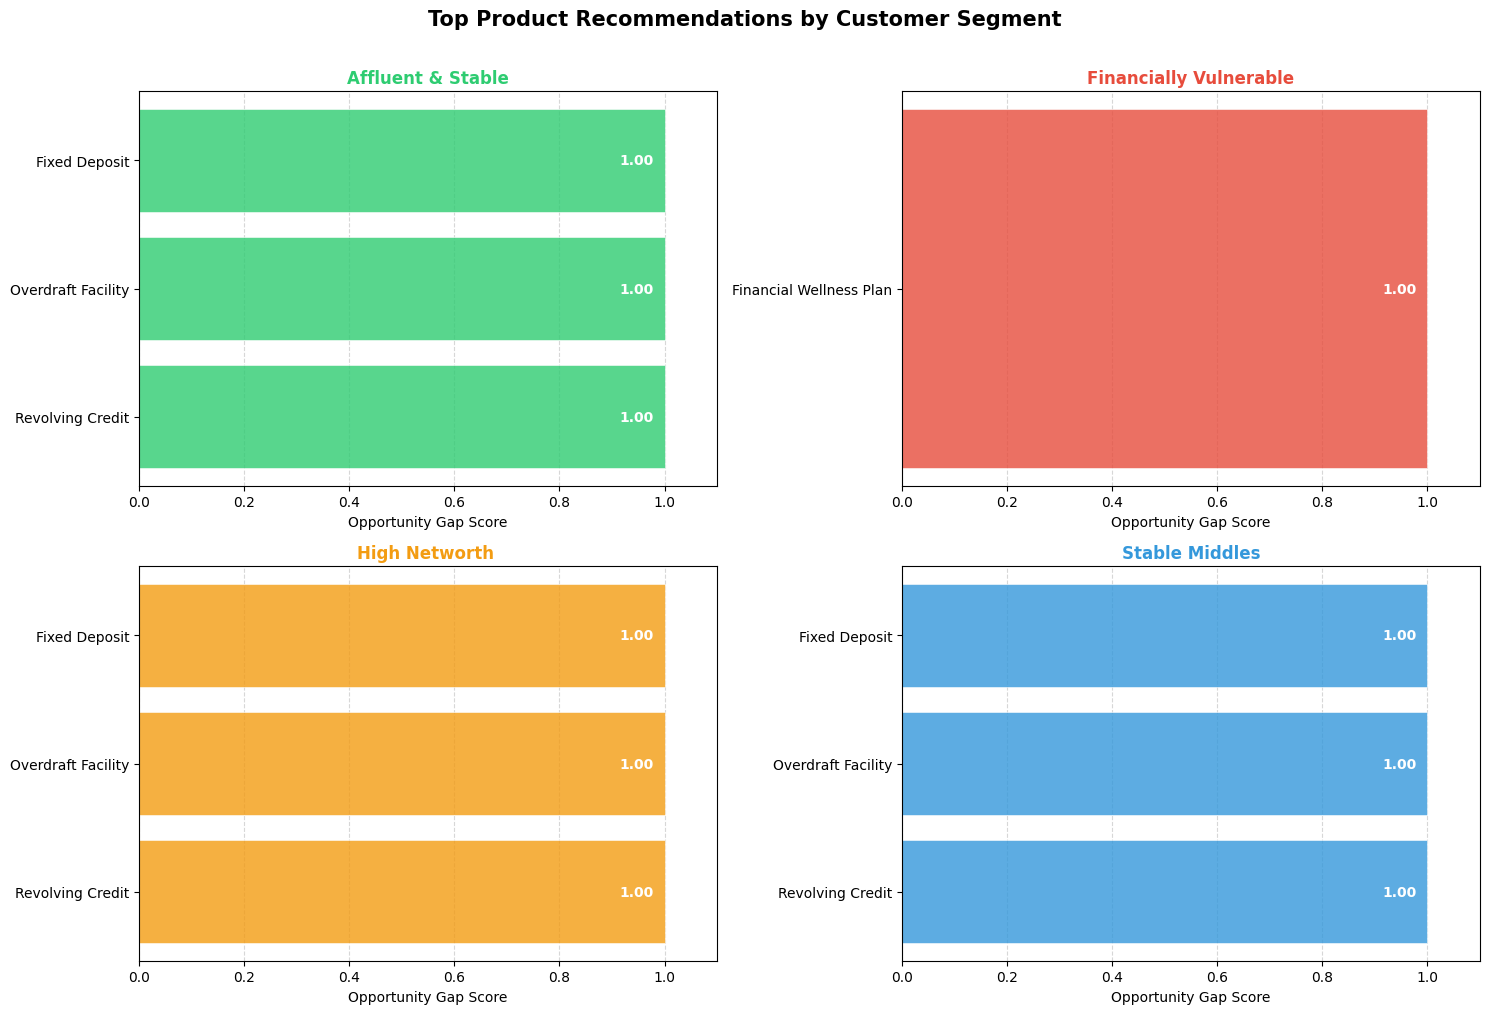

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

cluster_colors = {
    "Stable Middles":        "#3498db",
    "High Networth ":     "#f39c12",
    "Financially Vulnerable":"#e74c3c",
    "Affluent & Stable":   "#2ecc71"
}

for idx, (cluster_name, recs) in enumerate(cluster_recommendations.items()):
    products    = [r['product'] for r in recs]
    gap_scores  = [r['gap_score'] for r in recs]
    color       = cluster_colors[cluster_name]
    
    bars = axes[idx].barh(
        products, gap_scores,
        color=color, alpha=0.8, edgecolor='white', linewidth=0.5
    )
    
    # Add gap score labels on bars
    for bar, score in zip(bars, gap_scores):
        axes[idx].text(
            bar.get_width() - 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{score:.2f}',
            va='center', ha='right',
            color='white', fontweight='bold', fontsize=10
        )
    
    axes[idx].set_title(cluster_name, fontsize=12, fontweight='bold', color=color)
    axes[idx].set_xlabel("Opportunity Gap Score", fontsize=10)
    axes[idx].set_xlim(0, 1.1)
    axes[idx].xaxis.grid(True, linestyle='--', alpha=0.5)
    axes[idx].set_axisbelow(True)
    axes[idx].invert_yaxis()  # Highest gap at top

plt.suptitle("Top Product Recommendations by Customer Segment",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Predict Cluster Membership for a New Customer

In [52]:
# Train a classifier to predict cluster membership
from sklearn.ensemble import RandomForestClassifier



X_train  = df[raw_features]
y_train  = df['cluster']

classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced' 
)
classifier.fit(X_train, y_train)

# print(f"Classifier trained on {len(X_train)} customers")
# print(f"Training accuracy: {classifier.score(X_train, y_train):.3f}")


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [57]:
def predict_customer(customer_dict):
    """
    Predicts the cluster and recommended products for a new customer.
    
    Parameters
    ----------
    customer_dict : dict — new customer features (raw, unscaled values)
    
    Returns
    -------
    dict with cluster_id, cluster_name, and product recommendations
    """
    # Convert to DataFrame
    customer_df = pd.DataFrame([customer_dict])
    
    
    # Align columns with training data. Add missing columns as 0
    # to handle cases where a category wasn't seen in the new customer
    customer_features = df.reindex(
        columns=raw_features, fill_value=0
    )
    
    # Predict cluster
    predicted_cluster    = classifier.predict(customer_features)[0]
    predicted_cluster_name = cluster_names[predicted_cluster]
    
    # Get cluster profile for eligibility checking
    profile_row = cluster_profile.loc[predicted_cluster]
    
    # Override profile with actual customer values for more better recommendations
    profile_row = profile_row.copy()
    profile_row['monthly_income'] = customer_dict.get('monthly_income', profile_row['monthly_income'])
    profile_row['credit_score']   = customer_dict.get('credit_score',   profile_row['credit_score'])
    
    # Get recommendations
    recs = recommend_products_for_cluster(predicted_cluster_name, profile_row, top_n=3)
    
    print(f"\n{'=' * 55}")
    print(f"  NEW CUSTOMER PREDICTION")
    print(f"{'=' * 55}")
    print(f"  Predicted Segment : {predicted_cluster_name}")
    print(f"  Cluster ID        : {predicted_cluster}")
    print(f"\n  Recommended Products:")
    for i, rec in enumerate(recs, 1):
        print(f"  {i}. {rec['product']}")
        print(f"     → {rec['description']}")
    print(f"{'=' * 55}\n")
    
    return {
        'cluster_id':    predicted_cluster,
        'cluster_name':  predicted_cluster_name,
        'recommendations': recs
    }


In [58]:
# Try predicting a new customer
new_customer = {
    'age': 34,
    'gender': 'Female',
    'marital_status': 'Married',
    'number_of_dependents': 2,
    'education_level': 'Undergraduate',
    'province': 'Gauteng',
    'employment_status': 'Employed',
    'monthly_income': 35000,
    'savings_rate': 0.28,
    'account_tenure_years': 5,
    'monthly_transactions': 18,
    'avg_transaction_value': 850,
    'digital_login_frequency': 22,
    'branch_visit_count': 2,
    'late_payment_count': 0,
    'has_savings_account': 1,
    'has_credit_card': 1,
    'has_home_loan': 0,
    'has_personal_loan': 0,
    'has_vehicle_finance': 0,
    'has_investment_account': 0,
    'active_products_count': 2,
    'credit_score': 680,
    'loan_utilisation_rate': 0.25,
    'days_since_last_default': 0,
    'has_ever_defaulted': 0
}

result = predict_customer(new_customer)


  NEW CUSTOMER PREDICTION
  Predicted Segment : Stable Middles
  Cluster ID        : 3

  Recommended Products:
  1. Fixed Deposit
     → Guaranteed return savings over a fixed term
  2. Overdraft Facility
     → Short-term credit buffer linked to cheque account
  3. Revolving Credit
     → Flexible credit facility that replenishes as you repay

